DCGan-cifar10


In [ ]:
import torch
import numpy as np

print(torch.__version__)
print(np.__version__)


2.9.0+cu126
2.0.2


In [ ]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
from tqdm.notebook import tqdm



In [ ]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
dataroot = "/content/cifar10"
workers = 2
batch_size = 128
image_size = 32
nc = 3
nz = 100
ngf = 64
ndf = 64
num_epochs = 50
lr = 0.0002
beta1 = 0.5
ngpu = 1
manualSeed = 999


print(f"Random Seed: {manualSeed}")
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.cuda.manual_seed_all(manualSeed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Random Seed: 999
Using device: cuda:0


In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # Input: (batch, nz, 1, 1) -> Output: (batch, ngf*8, 4, 4)
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            # Input: (batch, ngf*8, 4, 4) -> Output: (batch, ngf*4, 8, 8)
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # Input: (batch, ngf*4, 8, 8) -> Output: (batch, ngf*2, 16, 16)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # Input: (batch, ngf*2, 16, 16) -> Output: (batch, nc, 32, 32)
            nn.ConvTranspose2d(ngf * 2, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)




In [ ]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)



In [ ]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
dataset = datasets.CIFAR10(
    root=dataroot,
    train=True,
    download=True,
    transform=transform
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers)
print(f"Dataset loaded: {len(dataset)} images")

Dataset loaded: 50000 images


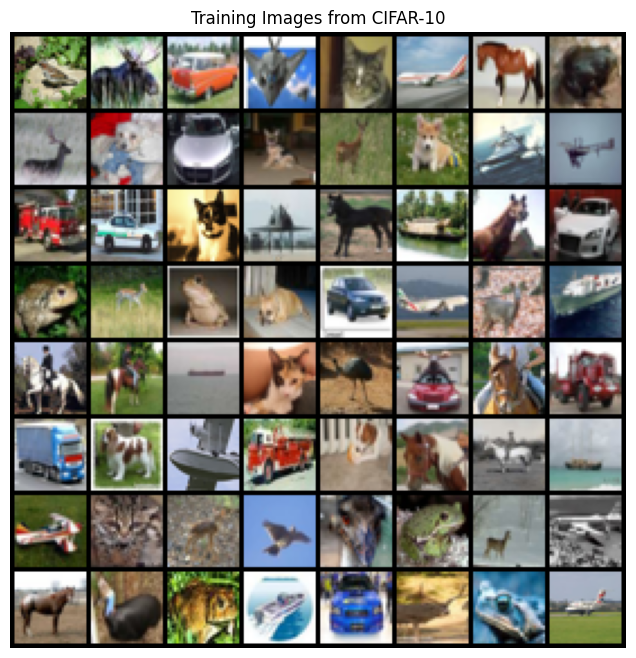

In [ ]:
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images from CIFAR-10")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:64], padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()

In [ ]:
netG = Generator(ngpu).to(device)
netG.apply(weights_init)
print("Generator:")
print(netG)

# d jinda kre ke liye
netD = Discriminator(ngpu).to(device)
netD.apply(weights_init)
print("\nDiscriminator:")
print(netD)


Generator:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Discriminator:
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv

In [ ]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
print("Training:")


Training:


In [ ]:
image_list=[]
G_losses=[]
D_losses=[]
Iters=0
print("Starting Training Loop...")
for epoch in range(num_epochs):
  Pbar=tqdm(enumerate(dataloader,0), total=len(dataloader), desc=f'Epoch{epoch+1}/{num_epochs}')
  for i, data in Pbar :
    netD.zero_grad()
    real_cpu=data[0].to(device)
    B_size=real_cpu.size(0)
    label=torch.full((B_size,), real_label, dtype=torch.float, device=device)
    Output=netD(real_cpu).view(-1)
    errD_real=criterion(Output, label)
    errD_real.backward()
    D_x=Output.mean().item()

    noise=torch.randn(B_size, nz, 1, 1, device=device)
    fake=netG(noise)
    label.fill_(fake_label)
    Output=netD(fake.detach()).view(-1)
    errD_fake=criterion(Output, label)
    errD_fake.backward()
    D_G_z1=Output.mean().item()
    errD=errD_real+errD_fake
    optimizerD.step()

    netG.zero_grad()
    label.fill_(real_label)
    Output=netD(fake).view(-1)
    errG=criterion(Output, label)
    errG.backward()
    D_G_z2=Output.mean().item()
    optimizerG.step()

    G_losses.append(errG.item())
    D_losses.append(errD.item())

    Pbar.set_postfix({
        'Loss_D': f'{errD.item():.4f}',
        'Loss_G': f'{errG.item():.4f}',
    })
    Iters += 1

  with torch.no_grad():
    fake = netG(fixed_noise).detach().cpu()
  image_list.append(vutils.make_grid(fake, padding=2, normalize=True))

  if (epoch+1) % 5 == 0:
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title(f"generated images - Epoch {epoch+1}")
    plt.imshow(np.transpose(image_list[-1], (1, 2, 0)))
    plt.show()

print("Training Complete")

Output hidden; open in https://colab.research.google.com to view.